# Development of a CNN Model with FFT as it's input features:

## Imports:

In [2]:
import tensorflow as tf
from scipy.fft import fft
import os
import scipy.io.wavfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Generating FFT:

In [4]:
def compute_fft_for_dataset(base_path='dataset/train'):

    fft_results = []
    labels = []

    print(f"Processando arquivos em: {base_path}")

    try:
        classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    except FileNotFoundError:
        print(f"Erro: O diretório '{base_path}' não foi encontrado.")
        return [], []

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        print(f"  - Lendo classe: {class_name}")

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith('.wav'):
                file_path = os.path.join(class_path, file_name)
                
                try:
                    # Carrega o áudio
                    sample_rate, audio_data = scipy.io.wavfile.read(file_path)

                    # Garante que o áudio é mono
                    if audio_data.ndim > 1:
                        audio_data = audio_data[:, 0]

                    # Calcula o FFT e a sua magnitude
                    # Apenas a primeira metade do resultado é útil (simetria)
                    N = len(audio_data)
                    fft_raw = fft(audio_data)
                    fft_magnitude = np.abs(fft_raw[:N//2])

                    # Armazena os resultados
                    fft_results.append(fft_magnitude)
                    labels.append(class_name)

                except Exception as e:
                    print(f"    - Erro ao processar o arquivo {file_name}: {e}")

    print("Processamento concluído.")
    return fft_results, labels

In [5]:
fft_data, fft_labels = compute_fft_for_dataset("./dataset/train")

fft_val_data, fft_val_labels = compute_fft_for_dataset("./dataset/validation")

fft_test, fft_test_labels = compute_fft_for_dataset("./dataset/test")

Processando arquivos em: ./dataset/train
  - Lendo classe: _silence_
  - Lendo classe: _unknown_
  - Lendo classe: go
  - Lendo classe: no
  - Lendo classe: off
  - Lendo classe: on
  - Lendo classe: stop
Processamento concluído.
Processando arquivos em: ./dataset/validation
  - Lendo classe: _silence_
  - Lendo classe: _unknown_
  - Lendo classe: go
  - Lendo classe: no
  - Lendo classe: off
  - Lendo classe: on
  - Lendo classe: stop
Processamento concluído.
Processando arquivos em: ./dataset/test
  - Lendo classe: _silence_
  - Lendo classe: _unknown_
  - Lendo classe: go
  - Lendo classe: no
  - Lendo classe: off
  - Lendo classe: on
  - Lendo classe: stop
Processamento concluído.


In [6]:
fft_data[0]

array([ 9840.        , 10892.47069929, 10185.30254863, ...,
       21708.19642257, 22568.2803379 , 37650.42860589])

Checking for Max Size for Padding:

In [7]:
tamanho_maximo = max(len(vetor) for vetor in fft_data)
tamanho_maximo

8000

In [8]:
fft_padded = tf.keras.preprocessing.sequence.pad_sequences(fft_data, maxlen=tamanho_maximo, padding='post', dtype='float32')

fft_val_padded = tf.keras.preprocessing.sequence.pad_sequences(fft_val_data, maxlen=tamanho_maximo, padding='post', dtype='float32')

fft_test_padded = tf.keras.preprocessing.sequence.pad_sequences(fft_test, maxlen=tamanho_maximo, padding='post', dtype="float32")

In [9]:
fft_padded.shape

(19201, 8000)

## Training:

In [10]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(fft_labels)
y_val_encoded = label_encoder.transform(fft_val_labels)
y_test_encoded = label_encoder.transform(fft_test_labels)

num_classes = len(label_encoder.classes_)
y_train_hot = tf.keras.utils.to_categorical(y_train_encoded, num_classes=num_classes)
y_val_hot = tf.keras.utils.to_categorical(y_val_encoded, num_classes=num_classes)
y_test_hot = tf.keras.utils.to_categorical(y_test_encoded, num_classes=num_classes)

In [15]:
model_fft_CNN = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(64, 3, activation='relu', input_shape=(fft_padded.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(256, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_fft_CNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 7998, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3999, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 3997, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1998, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1996, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1996, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 510976)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │   130,810,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,969,991 (499.61 MB)

 Trainable params: 130,968,711 (499.61 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [16]:
model_fft_CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [18]:
history = model_fft_CNN.fit(x=fft_padded, y=y_train_hot, callbacks=callbacks, validation_data=(fft_val_padded, y_val_hot), epochs=100, batch_size=32, verbose=1)

Epoch 1/100


I0000 00:00:1758249689.030057    6263 service.cc:152] XLA service 0x742e1c017460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758249689.030071    6263 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-18 23:41:29.070502: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758249689.265493    6263 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.1876 - loss: 2.8243

I0000 00:00:1758249692.040000    6263 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


601/601 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.5150 - loss: 1.2926 - val_accuracy: 0.4078 - val_loss: 1.7049
Epoch 2/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.6044 - loss: 1.0439 - val_accuracy: 0.5119 - val_loss: 1.2891
Epoch 3/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.6437 - loss: 0.9477 - val_accuracy: 0.6453 - val_loss: 0.9505
Epoch 4/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.6720 - loss: 0.8669 - val_accuracy: 0.6361 - val_loss: 0.9676
Epoch 5/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.7048 - loss: 0.7954 - val_accuracy: 0.5462 - val_loss: 1.3567
Epoch 6/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.7088 - loss: 0.7769 - val_accuracy: 0.6353 - val_loss: 1.0390
Epoch 7/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.7701 - loss: 0.6188 - val_accuracy: 0.6675 - val_loss: 0.9622
Epoch 8/100
601/601 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.8092 - loss: 0.5277 - val_

## Testing and Results:

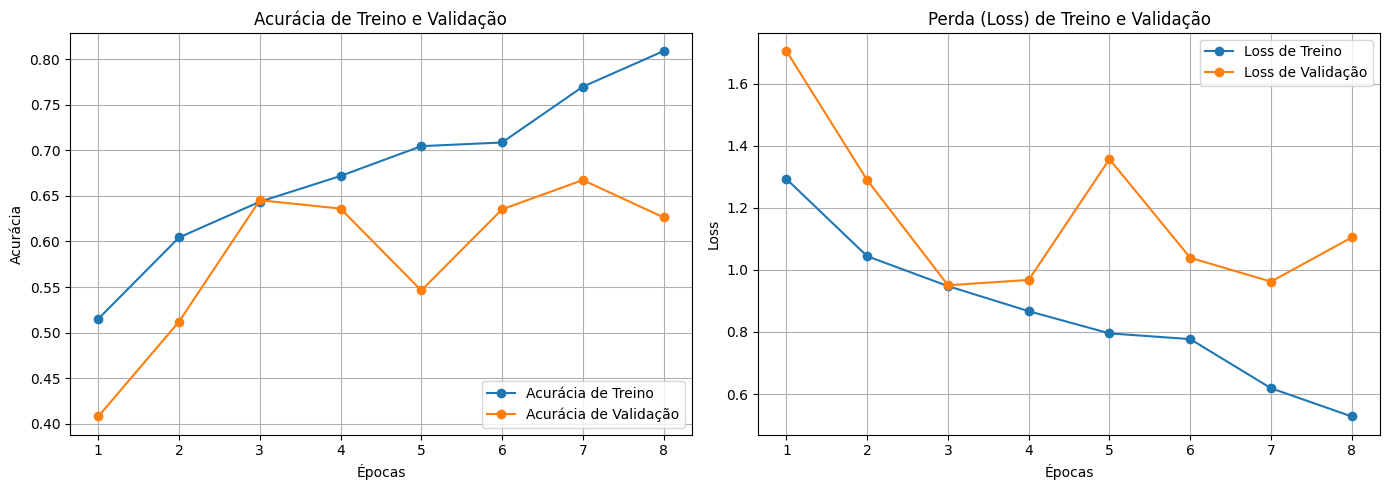

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [20]:
# Roda a predição. O resultado são as probabilidades de cada classe.
y_pred_probs = model_fft_CNN.predict(fft_test_padded)

# Converte as probabilidades para a classe com maior probabilidade (o índice)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Converte os labels verdadeiros (one-hot) para índices também
y_true_indices = np.argmax(y_test_hot, axis=1)

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [21]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=label_encoder.classes_)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       0.99      0.75      0.85       408
   _unknown_       0.43      0.64      0.51       466
          go       0.59      0.61      0.60       402
          no       0.63      0.44      0.52       405
         off       0.74      0.74      0.74       402
          on       0.70      0.57      0.63       396
        stop       0.67      0.76      0.71       411

    accuracy                           0.64      2890
   macro avg       0.68      0.64      0.65      2890
weighted avg       0.67      0.64      0.65      2890



--- Matriz de Confusão ---


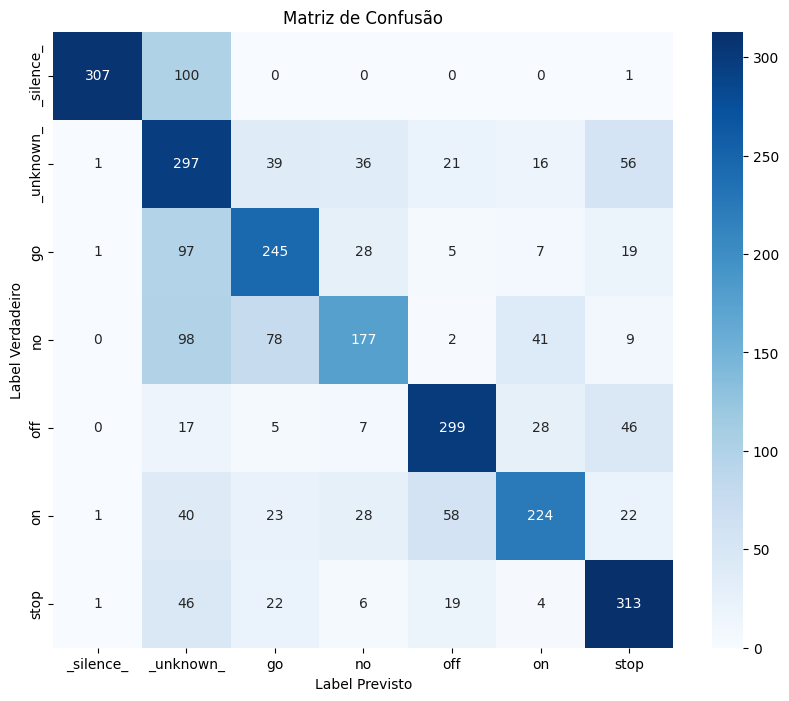

In [22]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()